In [196]:
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import defaultdict


In [197]:
datasource_progression_graph = pd.read_parquet("datasource_harmonic_novelty.parquet")


In [198]:
datasource_progression_graph['relation'].unique()

array(['modulated_by', 'associated_with', 'literature',
       'genetic_association', 'clinical_trial_Unknown/Operational',
       'rna_expression', 'affected_pathway', 'involved_in',
       'clinical_trial_positive', 'animal_model',
       'clinical_trial_unmet_efficacy', 'somatic_mutation',
       'clinical_trial_adverse_effects'], dtype=object)

In [199]:
subset = datasource_progression_graph[
    datasource_progression_graph['relation'] == 'clinical_trial_positive'
]

top_pair = (
    subset.groupby(['sourceId', 'targetId'])
          .size()
          .sort_values(ascending=False)
          .head(1)
)

print(top_pair)


sourceId         targetId   
ENSG00000095303  EFO_0003843    7
dtype: int64


In [200]:
datasource_progression_graph[((datasource_progression_graph["sourceId"] == "ENSG00000095303") & (datasource_progression_graph["targetId"] == "EFO_0003843"))].reset_index(drop=True)

,sourceId,targetId,source_type,target_type,relation,datasourceId,year,datasource_score,novelty,datasource_relation
0,ENSG00000095303,EFO_0003843,disease,target,clinical_trial_Unknown/Operational,chembl,2019,0.608273,0.597332,chembl::clinical_trial_Unknown/Operational
1,ENSG00000095303,EFO_0003843,disease,target,clinical_trial_Unknown/Operational,chembl,2022,0.714720,0.104533,chembl::clinical_trial_Unknown/Operational
2,ENSG00000095303,EFO_0003843,disease,target,clinical_trial_positive,chembl,2010,0.608273,0.597332,chembl::clinical_trial_positive
3,ENSG00000095303,EFO_0003843,disease,target,clinical_trial_positive,chembl,2011,0.714720,0.535765,chembl::clinical_trial_positive
4,ENSG00000095303,EFO_0003843,disease,target,clinical_trial_positive,chembl,2013,0.854538,0.137303,chembl::clinical_trial_positive
5,ENSG00000095303,EFO_0003843,disease,target,clinical_trial_positive,chembl,2015,0.884665,0.069909,chembl::clinical_trial_positive
6,ENSG00000095303,EFO_0003843,disease,target,clinical_trial_positive,chembl,2017,0.903343,0.018343,chembl::clinical_trial_positive
7,ENSG00000095303,EFO_0003843,disease,target,clinical_trial_positive,chembl,2019,0.905535,0.009339,chembl::clinical_trial_positive
8,ENSG00000095303,EFO_0003843,disease,target,clinical_trial_positive,chembl,2020,0.907236,0.002227,chembl::clinical_trial_positive
9,ENSG00000095303,EFO_0003843,disease,target,clinical_trial_unmet_efficacy,chembl,2012,0.212895,0.209066,chembl::clinical_trial_unmet_efficacy


In [201]:
datasource_progression_graph_small = datasource_progression_graph[~((datasource_progression_graph["datasource_score"] == 0) & (datasource_progression_graph["novelty"] == 0))].reset_index(drop=True)

In [202]:
datasource_progression_graph_small

,sourceId,targetId,source_type,target_type,relation,datasourceId,year,datasource_score,novelty,datasource_relation
0,CHEMBL1000,ENSG00000196639,molecule,target,modulated_by,chembl,2011,0.608273,0.597332,chembl::modulated_by
1,CHEMBL1009,ENSG00000151577,molecule,target,modulated_by,chembl,2011,0.608273,0.597332,chembl::modulated_by
2,CHEMBL1009,ENSG00000151577,molecule,target,modulated_by,chembl,2015,0.760341,0.149333,chembl::modulated_by
3,CHEMBL1017,ENSG00000144891,molecule,target,modulated_by,chembl,2013,0.760341,0.746665,chembl::modulated_by
4,CHEMBL103,ENSG00000082175,molecule,target,modulated_by,chembl,2017,0.760341,0.746665,chembl::modulated_by
...,...,...,...,...,...,...,...,...,...,...
60367,MONDO_0024622,R-HSA-5654219,disease,reactome,associated_with,slapenrich,2018,0.608273,0.597332,slapenrich::associated_with
60368,MONDO_0024622,R-HSA-68882,disease,reactome,associated_with,slapenrich,2018,0.608273,0.597332,slapenrich::associated_with
60369,MONDO_0024622,R-HSA-71288,disease,reactome,associated_with,slapenrich,2018,0.608273,0.597332,slapenrich::associated_with
60370,MONDO_0100096,R-HSA-9705671,disease,reactome,associated_with,reactome,2020,0.608273,0.597332,reactome::associated_with


In [203]:
def build_graph_schema(df):
    """
    Build a bidirectional, node-pair merged schema.
    Additionally aggregate (datasource + relation) into a single key.
    """

    df = df.copy()

    # ------------------------------------------------------------------
    # 1. Node types
    # ------------------------------------------------------------------
    node_types = set(df["source_type"].unique()) | set(df["target_type"].unique())

    # ------------------------------------------------------------------
    # 2. Relations (original)
    # ------------------------------------------------------------------
    edge_types = set(df["relation"].unique())

    # ------------------------------------------------------------------
    # 3. MERGE bidirectional node pairs
    # ------------------------------------------------------------------
    merged_relation_pairs = {}

    for row in df.itertuples():
        s = row.source_type
        t = row.target_type
        r = row.relation

        # unordered pair key
        key = tuple(sorted([s, t]))

        if key not in merged_relation_pairs:
            merged_relation_pairs[key] = set()

        merged_relation_pairs[key].add(r)

    relation_pairs = [
        (key, sorted(list(rels)))
        for key, rels in merged_relation_pairs.items()
    ]

    # ------------------------------------------------------------------
    # 4. Datasource–relation pairs
    # ------------------------------------------------------------------
    datasource_relation_map = (
        df.groupby("datasourceId")["datasource_relation"]
        .unique()
        .apply(lambda x: sorted(list(x)))
        .to_dict()
    )

    # ------------------------------------------------------------------
    # 5. Node-pair → datasource–relation mapping
    # ------------------------------------------------------------------
    nodepair_to_datasource_relation = {}

    for row in df.itertuples():
        s = row.source_type
        t = row.target_type
        dr = row.datasource_relation

        key = tuple(sorted([s, t]))

        if key not in nodepair_to_datasource_relation:
            nodepair_to_datasource_relation[key] = set()

        nodepair_to_datasource_relation[key].add(dr)

    nodepair_to_datasource_relation = {
        k: sorted(list(v)) for k, v in nodepair_to_datasource_relation.items()
    }

    # ------------------------------------------------------------------
    # Print summary
    # ------------------------------------------------------------------
    print("\n=== GRAPH SCHEMA SUMMARY (with datasource–relation aggregation) ===\n")
    print("Node types:", node_types)
    print("Edge relation types:", edge_types)

    print("\nNode-pair → Relations:")
    for pair, rels in relation_pairs:
        print(f"  {pair}: {rels}")

    print("\nDatasource → Datasource–Relation keys:")
    for ds, drs in datasource_relation_map.items():
        print(f"  {ds}: {drs}")

    print("\nNode-pair → Datasource–Relation keys:")
    for pair, drs in nodepair_to_datasource_relation.items():
        print(f"  {pair}: {drs}")

    print("\n=====================================================================\n")

    return {
        "node_types": node_types,
        "relation_pairs": relation_pairs,
        "datasource_relation_map": datasource_relation_map,
        "nodepair_to_datasource_relation": nodepair_to_datasource_relation,
    }


In [204]:
def build_schema_multigraph(schema):
    """
    Build a MultiGraph where each edge represents a datasource–relation pair.
    """

    G = nx.MultiGraph()

    # Add nodes
    for n in schema["node_types"]:
        G.add_node(n)

    # Add edges using datasource–relation pairs
    for (sourceId, targetId), dr_list in schema["nodepair_to_datasource_relation"].items():
        for dr in dr_list:  # e.g., "chembl::clinical_trial"
            datasource, relation = dr.split("::", 1)
            G.add_edge(
                sourceId, targetId,
                datasource=datasource,
                relation=relation,
                datasource_relation=dr
            )

    return G


In [205]:
def build_relation_colors(G, cmap_name="tab20"):
    import matplotlib.cm as cm

    # Unique relations
    relations = sorted({d["relation"] for _, _, _, d in G.edges(keys=True, data=True)})

    cmap = cm.get_cmap(cmap_name, len(relations))
    rel_to_color = {rel: cmap(i) for i, rel in enumerate(relations)}

    # Provide relation → index to help edge ordering
    rel_to_index = {rel: idx for idx, rel in enumerate(relations)}

    return rel_to_color, rel_to_index


def plot_schema_graph_curved_legends_spaced(
    G,
    figsize=(14, 12),
    node_spacing_scale=2.0,
    base_rad=0.15
):
    """
    Plot schema graph with:
        - non-overlapping, spaced-out nodes
        - curved multi-edges
        - colouring by RELATION
        - datasource-relation legend coloured by RELATION
        - multi-edge ordering sorted by relation colour index
        - legends anchored outside the plot
    """

    plt.figure(figsize=figsize)

    # ---------------------------------------------------------
    # 1. Compute spacious layout
    # ---------------------------------------------------------
    pos = nx.spring_layout(
        G, 
        seed=42,
        k=node_spacing_scale,      # bigger = more spacing
        iterations=200
    )

    # Expand layout slightly so edges do not touch frame
    pos = {n: (x*1.2, y*1.2) for n, (x, y) in pos.items()}

    # ---------------------------------------------------------
    # 2. Colours and ordering
    # ---------------------------------------------------------
    rel_to_color, rel_to_index = build_relation_colors(G)

    # Group edges by unordered node pairs
    parallel_edges = defaultdict(list)
    for (u, v, k, data) in G.edges(keys=True, data=True):
        pair = tuple(sorted([u, v]))
        parallel_edges[pair].append((u, v, k, data))

    # Sort edges inside each node-pair by relation index
    for pair in parallel_edges:
        parallel_edges[pair].sort(key=lambda x: rel_to_index[x[3]["relation"]])

    # ---------------------------------------------------------
    # 3. Draw nodes
    # ---------------------------------------------------------
    nx.draw_networkx_nodes(G, pos, node_size=2400, node_color="#CFE3FF")
    nx.draw_networkx_labels(G, pos, font_size=13, font_weight="bold")

    # ---------------------------------------------------------
    # 4. Draw curved, ordered, coloured edges
    # ---------------------------------------------------------
    for pair, edges in parallel_edges.items():
        total = len(edges)

        for idx, (u, v, k, data) in enumerate(edges):
            rel = data["relation"]
            color = rel_to_color[rel]

            # Balanced curvature
            if total == 1:
                rad = 0
            else:
                rad = base_rad * (idx - (total - 1) / 2)

            nx.draw_networkx_edges(
                G, pos,
                edgelist=[(u, v)],
                width=2.4,
                alpha=0.9,
                connectionstyle=f"arc3,rad={rad}",
                edge_color=[color]
            )

    # ---------------------------------------------------------
    # 5. Legends (relation + datasource–relation)
    # ---------------------------------------------------------

    # --- Legend 1: RELATIONS ---
    handles_rel = [
        plt.Line2D([0], [0], color=rel_to_color[rel], lw=4, label=rel)
        for rel in sorted(rel_to_color.keys())
    ]
    legend_rel = plt.legend(
        handles=handles_rel,
        title="Relation Types",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0)
    )
    plt.gca().add_artist(legend_rel)

    # --- Legend 2: DATASOURCE–RELATION ---
    ds_rel_unique = sorted({
        data["datasource_relation"]
        for _, _, _, data in G.edges(keys=True, data=True)
    })

    handles_dsrel = []
    for dr in ds_rel_unique:
        ds, rel = dr.split("::", 1)
        handles_dsrel.append(
            plt.Line2D([0], [0], color=rel_to_color[rel], lw=3, label=dr)
        )

    plt.legend(
        handles=handles_dsrel,
        title="Datasource–Relation",
        loc="upper left",
        bbox_to_anchor=(1.02, 0.35)
    )

    # ---------------------------------------------------------
    # Final layout
    # ---------------------------------------------------------
    plt.title("Temoral progression Graph Schema",
              fontsize=15)
    plt.axis("off")
    plt.tight_layout()
    plt.show()



=== GRAPH SCHEMA SUMMARY (with datasource–relation aggregation) ===

Node types: {'disease', 'reactome', 'target', 'molecule'}
Edge relation types: {'clinical_trial_adverse_effects', 'modulated_by', 'genetic_association', 'somatic_mutation', 'associated_with', 'clinical_trial_Unknown/Operational', 'rna_expression', 'clinical_trial_positive', 'animal_model', 'clinical_trial_unmet_efficacy', 'affected_pathway', 'literature', 'involved_in'}

Node-pair → Relations:
  ('molecule', 'target'): ['modulated_by']
  ('disease', 'reactome'): ['associated_with']
  ('disease', 'target'): ['affected_pathway', 'animal_model', 'clinical_trial_Unknown/Operational', 'clinical_trial_adverse_effects', 'clinical_trial_positive', 'clinical_trial_unmet_efficacy', 'genetic_association', 'literature', 'rna_expression', 'somatic_mutation']
  ('reactome', 'target'): ['involved_in']

Datasource → Datasource–Relation keys:
  cancer_biomarkers: ['cancer_biomarkers::somatic_mutation']
  cancer_gene_census: ['cancer_

/var/folders/k1/hcghm9xd1_qcbkz71tsp36fc0000gp/T/ipykernel_29929/1741387644.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(relations))


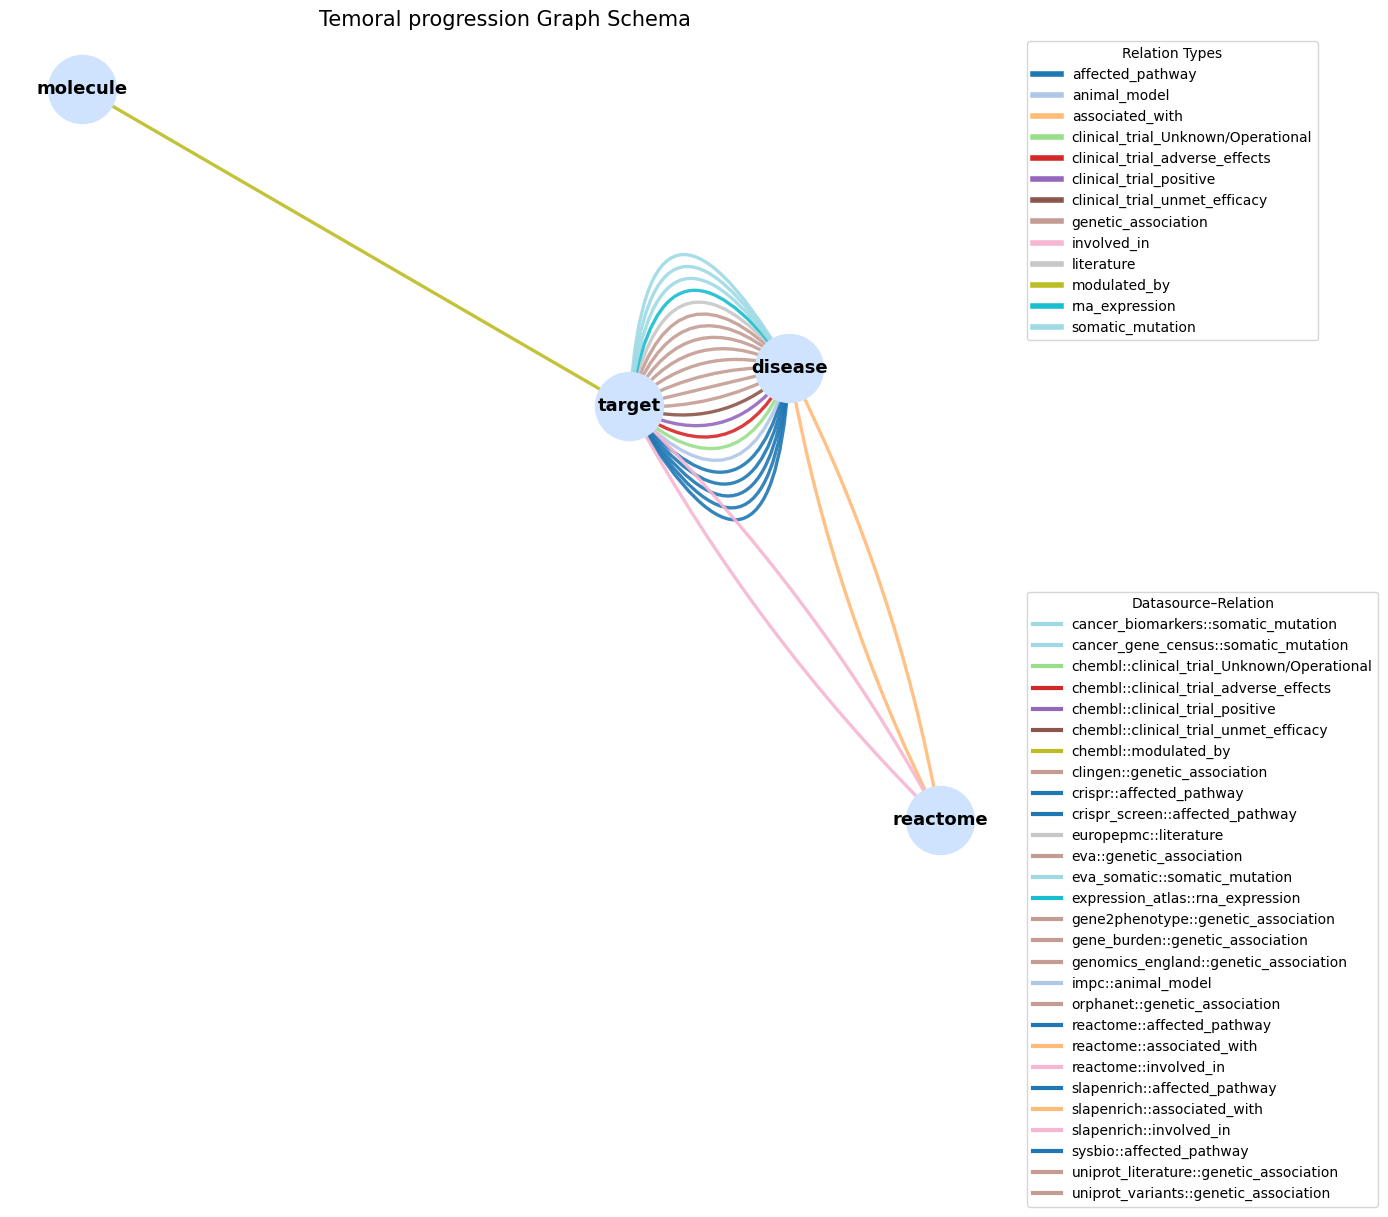

In [206]:
schema = build_graph_schema(datasource_progression_graph_small)
G = build_schema_multigraph(schema)
plot_schema_graph_curved_legends_spaced(G)

In [207]:
def count_edges_by_relation_and_datasource(df: pd.DataFrame) -> pd.DataFrame:
    """
    Produce a table counting number of edges grouped by:
        relation × datasourceId
    """
    table = (
        df.groupby(["source_type", "target_type", "relation", "datasourceId"])
          .size()
          .reset_index(name="edge_count")
          .sort_values(["relation", "datasourceId"])
    )
    return table

edge_table = count_edges_by_relation_and_datasource(datasource_progression_graph_small)

print(edge_table)



   source_type target_type                            relation  \
7       target     disease                    affected_pathway   
8       target     disease                    affected_pathway   
9       target     disease                    affected_pathway   
10      target     disease                    affected_pathway   
11      target     disease                    affected_pathway   
12      target     disease                        animal_model   
0      disease    reactome                     associated_with   
1      disease    reactome                     associated_with   
2      disease      target  clinical_trial_Unknown/Operational   
3      disease      target      clinical_trial_adverse_effects   
4      disease      target             clinical_trial_positive   
5      disease      target       clinical_trial_unmet_efficacy   
13      target     disease                 genetic_association   
14      target     disease                 genetic_association   
15      ta

In [208]:
import hashlib
import colorsys

GLASBEY_32 = [
    "#000000", "#ff0000", "#00ff00", "#0000ff", "#ffff00", "#00ffff", "#ff00ff",
    "#800000", "#008000", "#000080", "#808000", "#008080", "#800080",
    "#ff8080", "#80ff80", "#8080ff", "#ffff80", "#80ffff", "#ff80ff",
    "#ff8000", "#80ff00", "#00ff80", "#0080ff", "#8000ff",
    "#ff0080", "#00ff80", "#0080ff",
    "#c0c0c0", "#808080", "#404040", "#202020", "#e0e0e0"
]


def generate_edge_color_map(edge_types):
    """
    Assign each edge (relation) type a unique Glasbey colour.
    Works up to 32 relation types.
    """
    edge_types = sorted(edge_types)   # ensure deterministic order

    if len(edge_types) > len(GLASBEY_32):
        raise ValueError(
            f"Too many edge types ({len(edge_types)}). "
            f"Glasbey_32 supports max {len(GLASBEY_32)}."
        )

    return {
        et: GLASBEY_32[i]
        for i, et in enumerate(edge_types)
    }

def generate_node_color_map(node_types):
    """
    Assign each node type a Glasbey colour (first N entries).
    """
    node_types = sorted(node_types)

    if len(node_types) > len(GLASBEY_32):
        raise ValueError(
            f"Too many node types ({len(node_types)}). "
            f"Glasbey_32 supports max {len(GLASBEY_32)}."
        )

    return {
        nt: GLASBEY_32[i]
        for i, nt in enumerate(node_types)
    }



edge_types = datasource_progression_graph_small["datasource_relation"].unique()
edge_colors = generate_edge_color_map(edge_types)

node_types = set(datasource_progression_graph_small["source_type"]) | set(datasource_progression_graph_small["target_type"])
node_colors = generate_node_color_map(node_types)

In [209]:
def node_type_per_year(df):
    """
    Calculate the count of each node type per year in the given dataframe.
    """
    if "source_type" not in df.columns or "target_type" not in df.columns:
        return {}

    result = {}

    for y, sub in df.groupby("year"):
        nodes = pd.concat([
            sub[["sourceId", "source_type"]].rename(columns={"sourceId": "node", "source_type": "type"}),
            sub[["targetId", "target_type"]].rename(columns={"targetId": "node", "target_type": "type"})
        ]).drop_duplicates()

        result[y] = nodes["type"].value_counts().to_dict()

    return result

def edge_type_per_year(df):
    return {
        y: sub["datasource_relation"].value_counts().to_dict()
        for y, sub in df.groupby("year")
    }

def compute_drec(df):
    df = df.sort_values("year")
    years = sorted(df.year.unique())

    numer = 0
    denom = 0

    for i in range(len(years)-1):
        y = years[i]
        yn = years[i+1]

        E_t = set(map(tuple, df[df.year == y][["sourceId","targetId","datasource_relation"]].values))
        E_next = set(map(tuple, df[df.year == yn][["sourceId","targetId","datasource_relation"]].values))

        numer += len(E_t & E_next)
        denom += len(E_t)

    return numer / denom if denom else 0

def compute_rec(df):
    df = df.sort_values("year")
    seen = {}
    
    for y, sub in df.groupby("year"):
        edges = set(map(tuple, sub[["sourceId", "targetId", "datasource_relation"]].values))
        for e in edges:
            if e in seen:
                seen[e] = True
            else:
                seen[e] = False

    # proportion that repeated at least once
    return sum(seen.values()) / len(seen) if len(seen) else 0

from collections import defaultdict

def compute_consecutiveness(df):
    df = df.sort_values("year")
    years_by_edge = defaultdict(list)

    for _, row in df.iterrows():
        e = (row.sourceId, row.targetId, row.datasource_relation)
        years_by_edge[e].append(row.year)

    def max_run(years):
        years = sorted(years)
        longest = 1
        streak = 1
        for i in range(1, len(years)):
            if years[i] == years[i-1] + 1:
                streak += 1
                longest = max(longest, streak)
            else:
                streak = 1
        return longest

    runs = [max_run(yrs) for yrs in years_by_edge.values()]
    return sum(runs) / len(runs) if runs else 0

def compute_cumulative_evidence_diversity_per_year(df):
    """
    Computes cumulative evidence diversity (evidence maturation)
    for target-disease pairs across years.

    For each year y:
        diversity_y = avg number of distinct evidence types
                      ever observed for each TD pair up to year y
    """

    df = df.sort_values("year")

    # keep only target-disease edges (both directions allowed)
    td = df[
        ((df["source_type"] == "target") & (df["target_type"] == "disease")) |
        ((df["source_type"] == "disease") & (df["target_type"] == "target"))
    ]

    cumulative_support = {}      # {(sourceId, targetId): set(relation_types)}
    results = {}                 # {year: diversity_value}

    for y, sub in td.groupby("year"):
        # update cumulative evidence
        for _, row in sub.iterrows():
            pair = (row.sourceId, row.targetId)
            if pair not in cumulative_support:
                cumulative_support[pair] = set()
            cumulative_support[pair].add(row.datasource_relation)

        # compute cumulative diversity for this year
        if len(cumulative_support) > 0:
            diversities = [len(s) for s in cumulative_support.values()]
            results[y] = sum(diversities) / len(diversities)
        else:
            results[y] = 0.0

    return results

def compute_evidence_proportion_per_year(df):
    """
    Compute percentage proportion of each evidence type (datasource_relation)
    for every year in the dataset.

    Returns:
        pandas.DataFrame indexed by year
        columns = relation types
        values = proportion (0–1)
    """

    # count edges by (year, relation)
    prop = (
        df.groupby(["year", "datasource_relation"])
          .size()
          .reset_index(name="count")
    )

    # pivot → rows = years, cols = relation types
    pivot = prop.pivot(
        index="year",
        columns="datasource_relation",
        values="count"
    ).fillna(0)

    # normalise row-wise → percentage distribution
    pivot = pivot.div(pivot.sum(axis=1), axis=0)

    return pivot

def compute_evidence_counts_per_year(df):
    """
    Compute ABSOLUTE number of edges per evidence type (datasource_relation)
    for each year.

    Returns:
        pandas.DataFrame indexed by year,
        columns = relation types,
        values = absolute counts (int)
    """

    # count edges by (year, relation)
    counts = (
        df.groupby(["year", "datasource_relation"])
          .size()
          .reset_index(name="count")
    )

    # pivot → rows = years, cols = relation types
    pivot = counts.pivot(
        index="year",
        columns="datasource_relation",
        values="count"
    ).fillna(0)

    return pivot



In [214]:
def compute_dataset_stats(df):
    stats = {}

    # Basic dataset-level stats
    stats["# Quadruples"] = len(df)
    stats["# Nodes"] = len(set(df["sourceId"]).union(set(df["targetId"])))
    stats["# Edge Types"] = df["datasource_relation"].nunique()
    stats["# Node Types"] = len(set(df["source_type"]).union(df["target_type"]))
    stats["# Timesteps"] = df["year"].nunique()
    stats["Granularity"] = "year"

    # mean edges per year
    edges_per_year = df.groupby("year").size()
    stats["Mean Edges/Ts."] = edges_per_year.mean()

    # mean nodes per year
    nodes_per_year = (
        df.groupby("year")[["sourceId", "targetId"]]
          .agg(lambda s: len(set(s)))
          .sum(axis=1)
    )
    stats["Mean Nodes/Ts."] = nodes_per_year.mean()

    # ------ Module 3 metrics ------
    # FIX: removed trailing commas (those created tuples)
    stats["Direct Recurrency (DRec)"] = compute_drec(df)
    stats["Recurrency (Rec)"] = compute_rec(df)
    stats["Consecutiveness (Con)"] = compute_consecutiveness(df)

    return stats

def compute_plot_stats(df, split_year=None):
    df = df.sort_values("year")

    if split_year is None:
        split_year = int(np.median(df.year.unique()))

    stats = {
        "node_type_per_year": node_type_per_year(df),
        "edge_type_per_year": edge_type_per_year(df),
        "cumulative_evidence_diversity": compute_cumulative_evidence_diversity_per_year(df),
        "harmonic_sum_distribution": (
            df.groupby("datasource_relation")["datasource_score"]
              .apply(list)
              .to_dict()
        ),
        ""
        "evidence_proportion_per_year": compute_evidence_proportion_per_year(df),
        "evidence_count_per_year": compute_evidence_counts_per_year(df)
    }

    return stats



In [ ]:
def plot_edge_type_per_year(edge_type_dict, edge_color_map):
    plt.figure(figsize=(14,7))

    years = sorted(edge_type_dict.keys())
    all_rels = sorted({r for ydata in edge_type_dict.values() for r in ydata})

    for r_name in all_rels:
        vals = [edge_type_dict[y].get(r_name, 0) for y in years]
        color = edge_color_map.get(r_name, "#999999")  # fallback grey
        plt.plot(years, vals, marker='o', label=r_name, color=color)

    plt.title("Edge Types Per Year")
    plt.xlabel("Year")
    plt.ylabel("Edge Count")
    plt.xticks(rotation=45)

    # Legend scroll for many relations
    plt.legend(
        title="Relation Type",
        bbox_to_anchor=(1.05, 1),
        loc='upper left'
    )

    plt.tight_layout()
    plt.show()
    
def plot_node_type_per_year(node_type_dict, node_color_map):
    plt.figure(figsize=(12,6))

    years = sorted(node_type_dict.keys())
    all_types = sorted({t for d in node_type_dict.values() for t in d})

    for t_name in all_types:
        vals = [node_type_dict[y].get(t_name, 0) for y in years]
        color = node_color_map.get(t_name, "#999999")
        plt.plot(years, vals, marker='o', label=t_name, color=color)

    plt.title("Node Types Per Year")
    plt.xlabel("Year")
    plt.ylabel("Node Count")
    plt.xticks(rotation=45)
    plt.legend(title="Node Type")
    plt.tight_layout()
    plt.show()

def plot_cumulative_evidence_diversity(stats):
    years = sorted(stats.keys())
    vals = [stats[y] for y in years]

    plt.figure(figsize=(10,5))
    plt.plot(years, vals, marker="o")
    plt.title("Cumulative Evidence Diversity (Evidence Maturation)")
    plt.xlabel("Year")
    plt.ylabel("Distinct Evidence Types (Cumulative)")
    plt.tight_layout()
    plt.show()
    

def plot_score_distribution(df, max_relations=30):
    """
    Score distribution per relation type.
    Uses seaborn violin + box overlay.
    """

    rel_counts = df["datasource_relation"].nunique()
    if rel_counts > max_relations:
        print(f"⚠️ Too many relation types ({rel_counts}), showing first {max_relations}.")
        df = df[df["datasource_relation"].isin(
            df["datasource_relation"].unique()[:max_relations]
        )]

    plt.figure(figsize=(14, max(6, rel_counts * 0.4)))

    sns.violinplot(
        data=df,
        x="score",
        y="datasource_relation",
        scale="width",
        inner=None,
        cut=0
    )
    sns.boxplot(
        data=df,
        x="score",
        y="datasource_relation",
        showcaps=True,
        boxprops={'facecolor':'none'},
        showfliers=False,
        whiskerprops={'linewidth':1.5}
    )

    plt.title("Score Distribution per Relation Type")
    plt.xlabel("Score")
    plt.ylabel("Relation Type")
    plt.tight_layout()
    plt.show()

def plot_score_percentage(score_dist, edge_color_map, bins=50):

    plt.figure(figsize=(12,7))

    for rel, scores in score_dist.items():
        scores = np.array(scores)

        # histogram → percentage
        counts, bin_edges = np.histogram(scores, bins=bins, range=(0,1))
        pct = counts / counts.sum() * 100
        centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        plt.plot(
            centers, pct,
            color=edge_color_map.get(rel, "#888888"),
            label=rel,
            linewidth=2
        )

    plt.title("Score Distribution per Relation Type (Percentage)")
    plt.xlabel("Score")
    plt.ylabel("Percentage of Samples (%)")
    plt.xlim(0, 1)
    plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
    plt.tight_layout()
    plt.show()

def plot_evidence_proportion_per_year(pivot_df, edge_color_map):
    modalities = pivot_df.columns.tolist()
    colors = [edge_color_map.get(m, "#999999") for m in modalities]

    pivot_df.plot(
        kind="bar",
        stacked=True,
        figsize=(15, 7),
        color=colors,
        width=0.9
    )

    plt.title("Proportion of Evidence Types per Year")
    plt.xlabel("Year")
    plt.ylabel("Proportion")
    plt.legend(title="Relation Type", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

def plot_evidence_counts_per_year(pivot_df, edge_color_map):
    """
    Stacked bar plot of absolute number of edges per year,
    one bar per year, stacked by evidence type.
    """

    modalities = pivot_df.columns.tolist()
    colors = [edge_color_map.get(m, "#999999") for m in modalities]

    pivot_df.plot(
        kind="bar",
        stacked=True,
        figsize=(15, 7),
        color=colors,
        width=0.9
    )

    plt.title("Absolute Number of Evidence Edges per Year")
    plt.xlabel("Year")
    plt.ylabel("Number of Edges")
    plt.legend(title="Relation Type", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


In [222]:
dataset_stats = compute_dataset_stats(datasource_progression_graph_small)
pd.DataFrame(dataset_stats.items(), columns=["Statistic", "Value"])


,Statistic,Value
0,# Quadruples,60372
1,# Nodes,16392
2,# Edge Types,28
3,# Node Types,4
4,# Timesteps,15
5,Granularity,year
6,Mean Edges/Ts.,4024.8
7,Mean Nodes/Ts.,3544.533333
8,Direct Recurrency (DRec),0.142886
9,Recurrency (Rec),0.173384


In [223]:
plot_stats = compute_plot_stats(datasource_progression_graph_small)


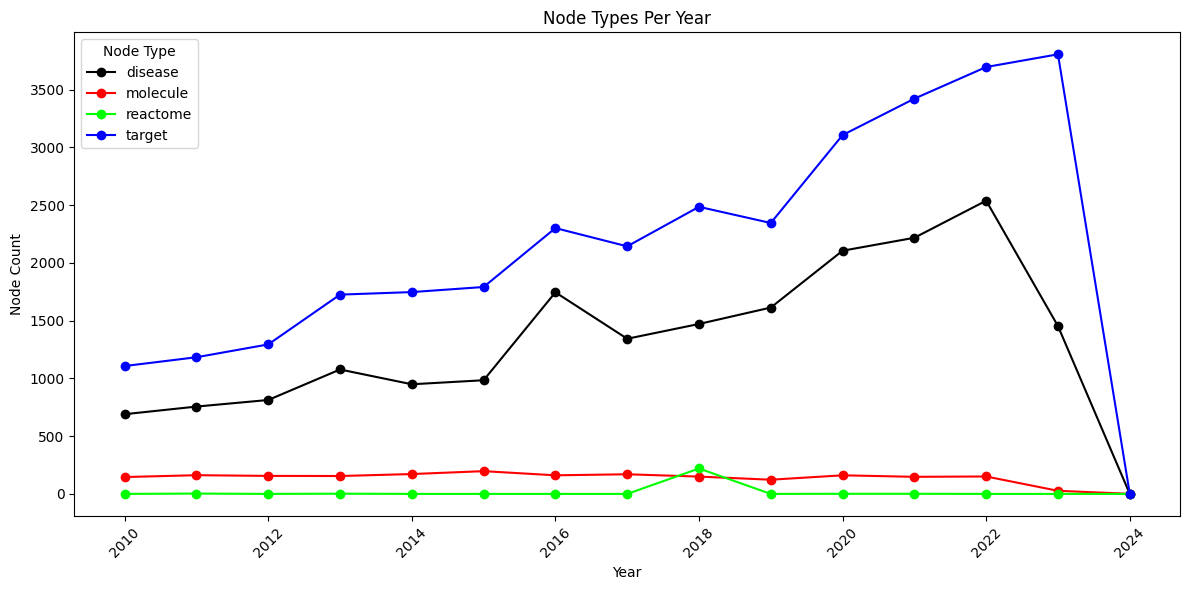

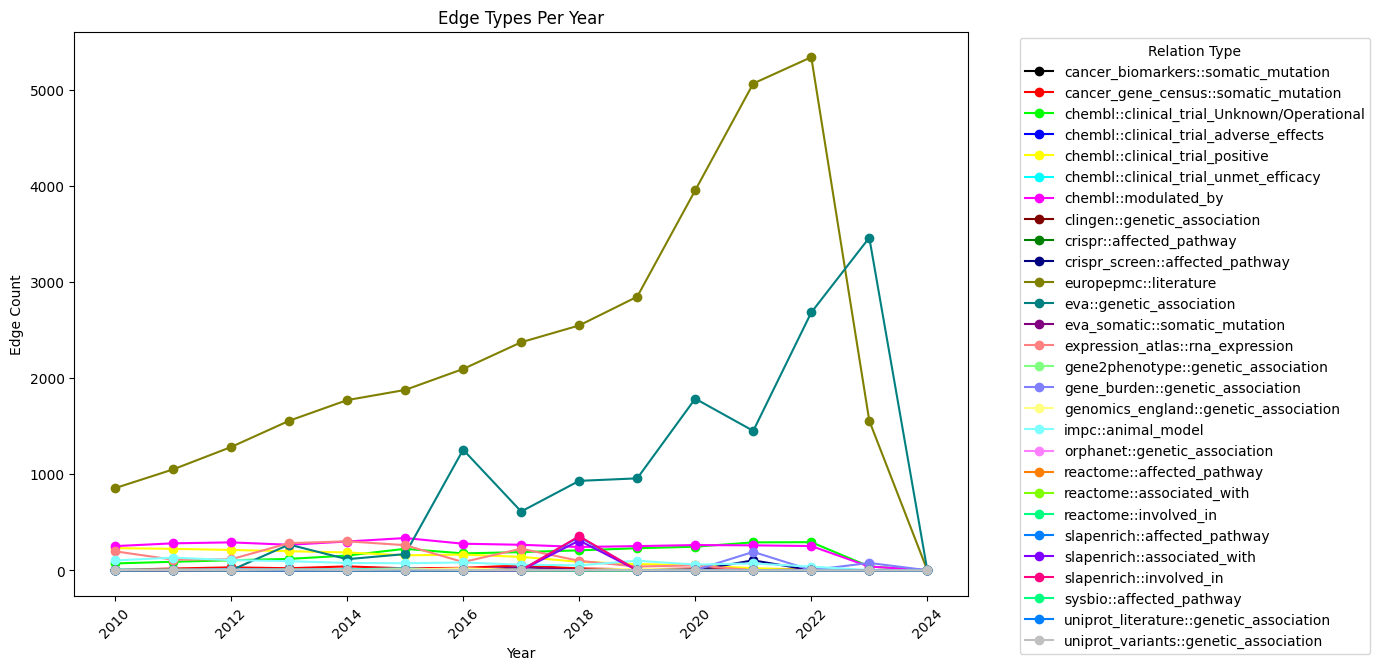

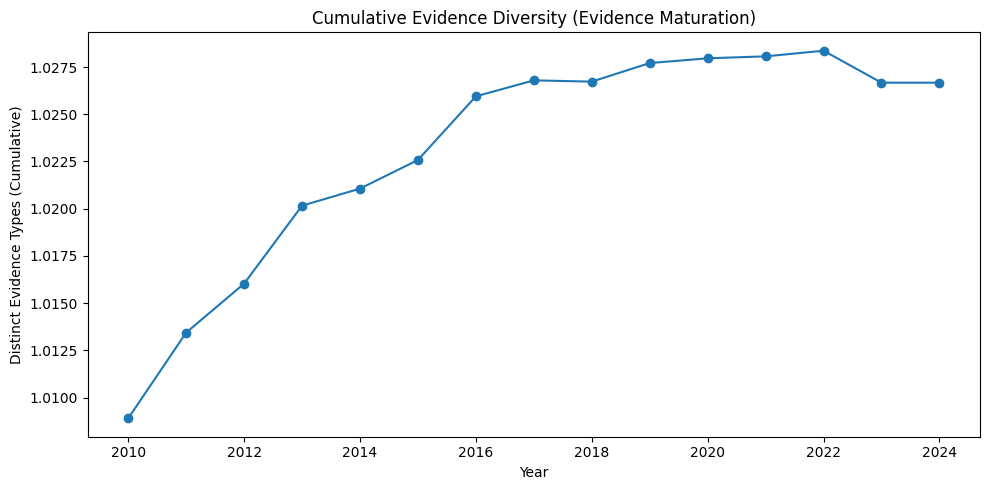

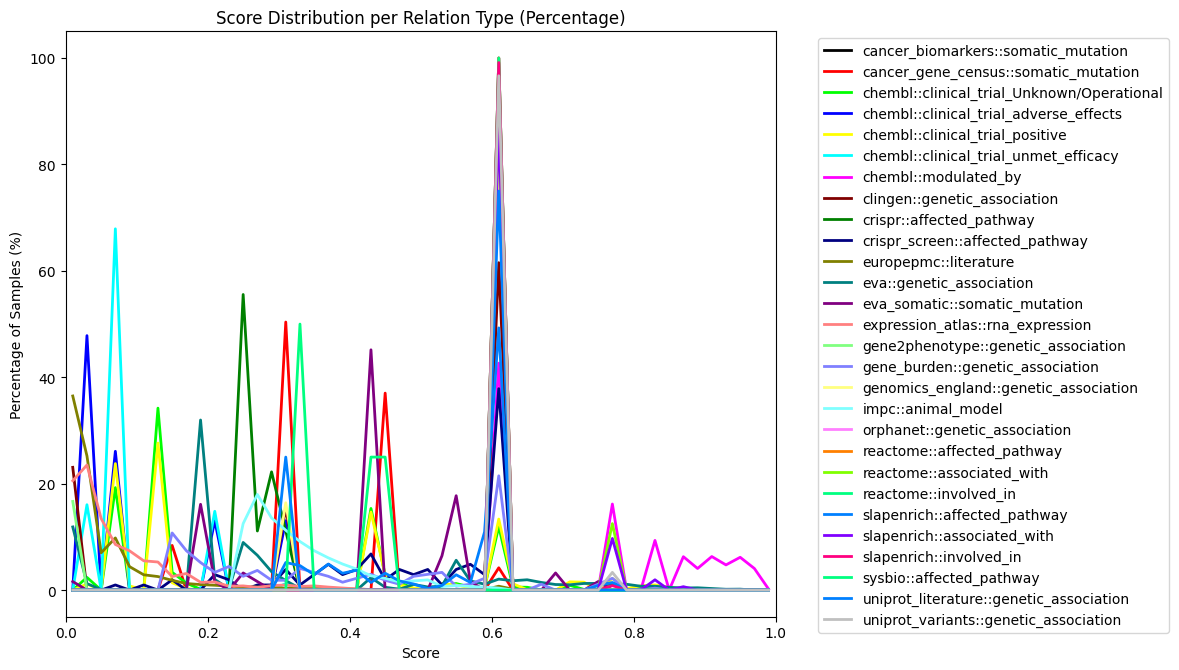

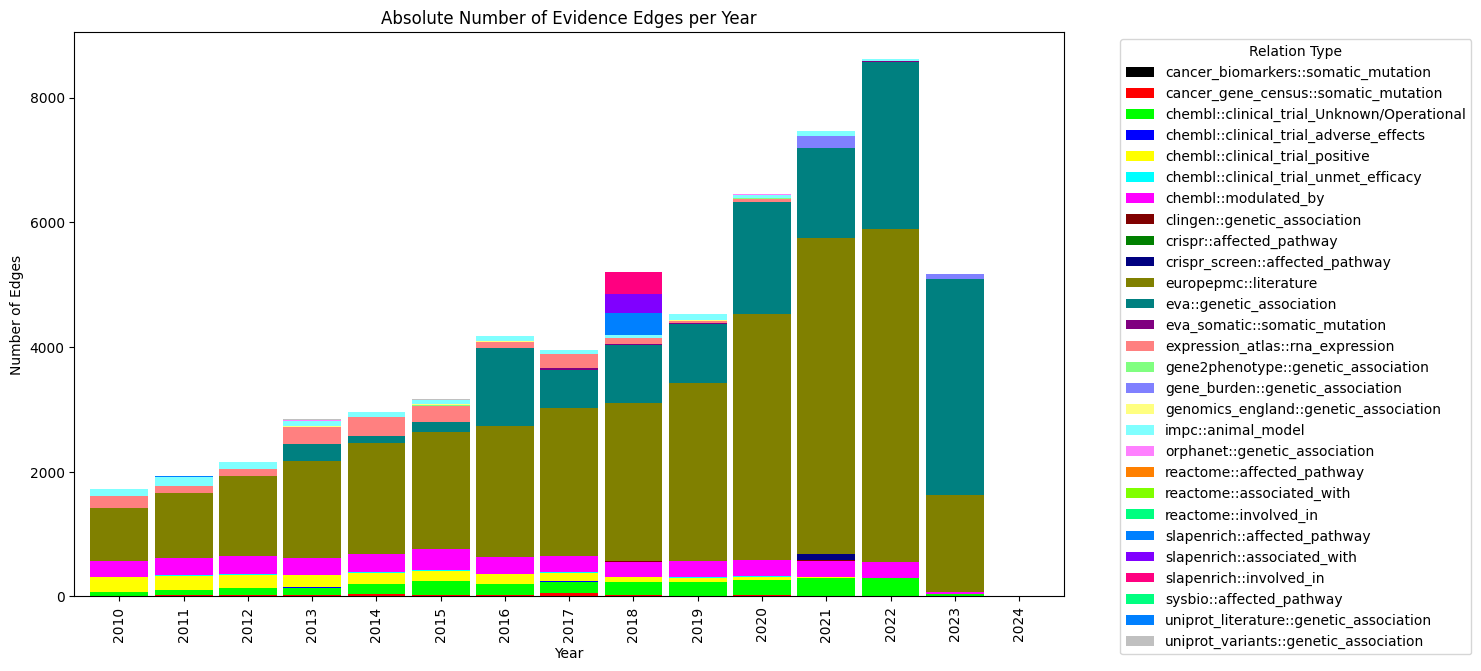

In [224]:
plot_node_type_per_year(plot_stats["node_type_per_year"], node_colors)
plot_edge_type_per_year(plot_stats["edge_type_per_year"], edge_colors)
plot_cumulative_evidence_diversity(plot_stats["cumulative_evidence_diversity"])
plot_score_percentage(plot_stats["harmonic_sum_distribution"], edge_colors)
# plot_evidence_proportion_per_year(plot_stats['evidence_proportion_per_year'], edge_color_map=edge_colors)
plot_evidence_counts_per_year(plot_stats['evidence_count_per_year'], edge_color_map=edge_colors)
